In [18]:
#House_Price_and_Category_Prediction
#Name : Muddassir Kazi
#Roll No : 24F-AI-115


In [19]:
#Importing core modules data handling, preprocessing, modeling and evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

#Load Dataset
df = pd.read_csv('House_price_pred_train.csv')

#Select numerical features for price estimation
selected_features=['LotArea', 'GrLivArea', 'TotRmsAbvGrd', 'OverallQual', 'YearBuilt']
target_feature='SalePrice'

#Keeping relevent columns
df = df[selected_features + [target_feature]]

print("Dataset Head")
print(df.head())
print("\n Missing Value count")
print(df.isnull().sum())

Dataset Head
   LotArea  GrLivArea  TotRmsAbvGrd  OverallQual  YearBuilt  SalePrice
0     8450       1710             8            7       2003     208500
1     9600       1262             6            6       1976     181500
2    11250       1786             6            7       2001     223500
3     9550       1717             7            7       1915     140000
4    14260       2198             9            8       2000     250000

 Missing Value count
LotArea         0
GrLivArea       0
TotRmsAbvGrd    0
OverallQual     0
YearBuilt       0
SalePrice       0
dtype: int64


In [20]:
#DATA PREPROCESSING

#Handling missing values
df.fillna(df.median(), inplace=True)

#Removing Outliers using IQR Method
Q1= df['SalePrice'].quantile(0.25)
Q3= df['SalePrice'].quantile(0.75)
IQR= Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

initial_count=len(df)
df=df[(df['SalePrice'] >=lower_bound) & (df['SalePrice'] <=upper_bound)]
print(f"Outlier Removal: Removed {initial_count-len(df)}.rows")

#Categorize target into low,medium,high
df['Price_Category'] = pd.qcut(df['SalePrice'], q=3, labels=['low','medium','high'])
print("\n Price Category Distribution")
print(df['Price_Category'].value_counts())

Outlier Removal: Removed 61.rows

 Price Category Distribution
Price_Category
low       468
high      466
medium    465
Name: count, dtype: int64


In [21]:
#FEATURE SCALING AND TRAIN,TEST,SPLIT

X = df[selected_features]
y_cont = df['SalePrice']
y_disc = df['Price_Category']

X_train, X_test, y_train_cont, y_test_cont, y_train_disc, y_test_disc = train_test_split(X, y_cont, y_disc, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training_samples: {X_train_scaled.shape[0]}, Test_samples: {X_test_scaled.shape[0]}")

Training_samples: 1119, Test_samples: 280


In [22]:
#MODEL TRAINING AND EVALUATION

regressor=LinearRegression()
regressor.fit(X_train_scaled,y_train_cont)

y_pred_cont=regressor.predict(X_test_scaled)
rmse =  np.sqrt(mean_squared_error(y_test_cont,y_pred_cont))
r2 = r2_score(y_test_cont,y_pred_cont)
print("----------------")
print("MODEL 1: LINEAR REGRESSION PERFORMANCE")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")
print("----------------")


----------------
MODEL 1: LINEAR REGRESSION PERFORMANCE
RMSE: 25969.420454373372
R2 Score: 0.7879756319058187
----------------


In [23]:
#MODEL TRAINING AND EVALUATION

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train_scaled, y_train_disc)

y_pred_disc = classifier.predict(X_test_scaled)
accuracy = accuracy_score(y_test_disc, y_pred_disc)
classification_rep = classification_report(y_test_disc, y_pred_disc)
confusion_mat = confusion_matrix(y_test_disc, y_pred_disc)

print("----------------")
print("MODEL 2: RANDOM FOREST CLASSIFIER PERFORMANCE")
print(f"Accuracy_score: {accuracy*100:.2f}%")
print(f"Classification Report:\n{classification_rep}\n")
print(f"Confusion Matrix:\n{confusion_mat}\n")

----------------
MODEL 2: RANDOM FOREST CLASSIFIER PERFORMANCE
Accuracy_score: 77.14%
Classification Report:
              precision    recall  f1-score   support

        high       0.81      0.83      0.82        81
         low       0.83      0.77      0.80        92
      medium       0.70      0.73      0.72       107

    accuracy                           0.77       280
   macro avg       0.78      0.78      0.78       280
weighted avg       0.77      0.77      0.77       280


Confusion Matrix:
[[67  0 14]
 [ 2 71 19]
 [14 15 78]]



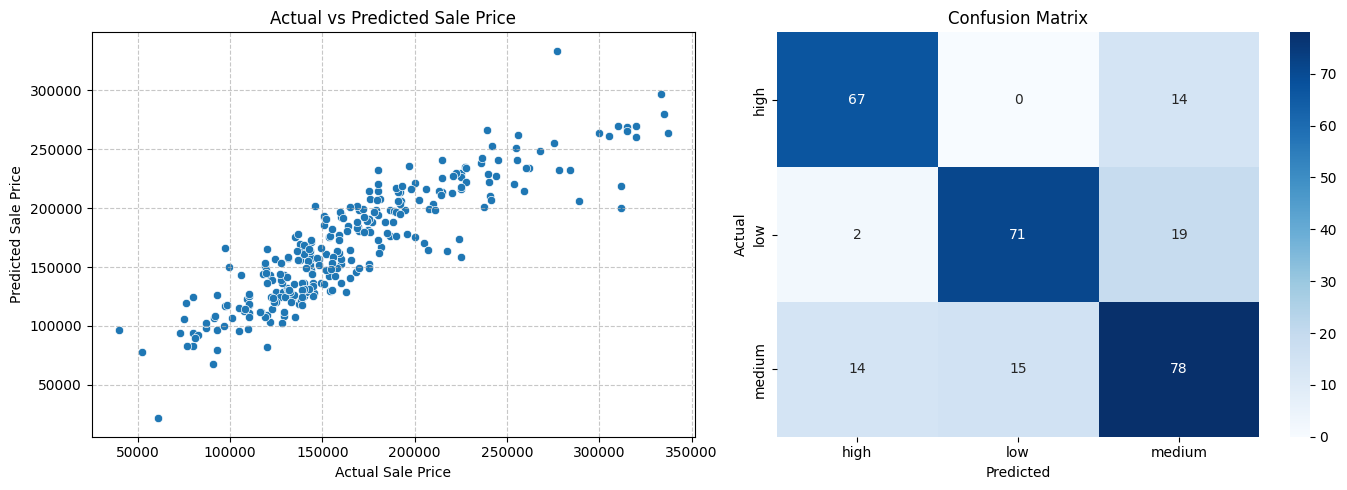

In [24]:
# Fit the regression model to define y_pred_cont
regressor = LinearRegression()
regressor.fit(X_train_scaled, y_train_cont)
y_pred_cont = regressor.predict(X_test_scaled)

# VISUALIZING
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_cont, y=y_pred_cont)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price")
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test_disc, y_pred_disc, labels=classifier.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()